# Hierarchical IDS — Fallback & Overlap Analysis

This notebook analyses:
- Ambiguous regions in M1 routing scores
- Confidence-based fallback after M3
- Safety impact of fallback (true attack loss)
- Scenario-level composition of overlapping samples

All models and routing thresholds are fixed from Notebook 1.
No training or tuning is performed here.

In [6]:
# -------------------------------
# 0. LOOKUP Dictionary
# -------------------------------
SCENARIO_LOOKUP = {
    # Natural Faults (1–6)
    1: "Fault L1 (10–19%)",
    2: "Fault L1 (20–79%)",
    3: "Fault L1 (80–90%)",
    4: "Fault L2 (10–19%)",
    5: "Fault L2 (20–79%)",
    6: "Fault L2 (80–90%)",

    # Maintenance (13–14)
    13: "Line Maintenance L1",
    14: "Line Maintenance L2",

    # Data Injection Attacks (7–12)
    7:  "Data Injection: L1 Fault 10–19% with tripping",
    8:  "Data Injection: L1 Fault 20–79% with tripping",
    9:  "Data Injection: L1 Fault 80–90% with tripping",
    10: "Data Injection: L2 Fault 10–19% with tripping",
    11: "Data Injection: L2 Fault 20–79% with tripping",
    12: "Data Injection: L2 Fault 80–90% with tripping",

    # Remote Tripping Attacks (15–20)
    15: "Remote Tripping: Command Injection R1",
    16: "Remote Tripping: Command Injection R2",
    17: "Remote Tripping: Command Injection R3",
    18: "Remote Tripping: Command Injection R4",
    19: "Remote Tripping: Command Injection R1 & R2",
    20: "Remote Tripping: Command Injection R3 & R4",

    # Relay Setting Change (21–30)
    21: "Relay Setting Change: R1 disabled (L1 10–19% fault)",
    22: "Relay Setting Change: R1 disabled (L1 20–90% fault)",
    23: "Relay Setting Change: R2 disabled (L1 10–49% fault)",
    24: "Relay Setting Change: R2 disabled (L1 50–79% fault)",
    25: "Relay Setting Change: R2 disabled (L1 80–90% fault)",
    26: "Relay Setting Change: R3 disabled (L2 10–19% fault)",
    27: "Relay Setting Change: R3 disabled (L2 20–49% fault)",
    28: "Relay Setting Change: R3 disabled (L2 50–90% fault)",
    29: "Relay Setting Change: R4 disabled (L2 10–79% fault)",
    30: "Relay Setting Change: R4 disabled (L2 80–90% fault)",

    # Relay Setting Change (two relays + fault)
    35: "Relay Setting Change: R1 & R2 disabled (L1 10–49% fault)",
    36: "Relay Setting Change: R1 & R2 disabled (L1 50–90% fault)",
    37: "Relay Setting Change: R3 & R4 disabled (L1 10–49% fault)",
    38: "Relay Setting Change: R3 & R4 disabled (L1 50–90% fault)",

    # Relay Setting Change (two relays + maintenance)
    39: "Relay Setting Change: R1 & R2 disabled during maintenance",
    40: "Relay Setting Change: R1 & R2 disabled during maintenance",

    # Normal Operation
    41: "Normal Operation (no disturbances)"
}

DI_NAMES = {
    7: "DI: Fault 10–19% L1",
    8: "DI: Fault 20–79% L1",
    9: "DI: Fault 80–90% L1",
    10: "DI: Fault 10–19% L2",
    11: "DI: Fault 20–79% L2",
    12: "DI: Fault 80–90% L2"
}

RT_NAMES = {
    15: "Remote Trip: Cmd R1",
    16: "Remote Trip: Cmd R2",
    17: "Remote Trip: Cmd R3",
    18: "Remote Trip: Cmd R4",
    19: "Remote Trip: Cmd R1 & R2",
    20: "Remote Trip: Cmd R3 & R4"
}

RSC_NAMES = {
    21: "RSC: L1 R1 Disabled (10–19%)",
    22: "RSC: L1 R1 Disabled (20–90%)",
    23: "RSC: L1 R2 Disabled (10–49%)", 
    24: "RSC: L1 R2 Disabled (50–79%)",
    25: "RSC: L1 R2 Disabled (80–90%)",
    26: "RSC: L2 R3 Disabled (10–19%)",
    27: "RSC: L2 R3 Disabled (20–49%)",
    28: "RSC: L2 R3 Disabled (50–90%)",
    29: "RSC: L2 R4 Disabled (10–79%)",
    30: "RSC: L2 R4 Disabled (80–90%)",
    35: "RSC: L1 R1&R2 Disabled (10–49%)",
    36: "RSC: L1 R1&R2 Disabled (50–90%)",
    37: "RSC: L1 R3&R4 Disabled (10–49%)",
    38: "RSC: L1 R3&R4 Disabled (50–90%)",
    39: "RSC: L1 Maint R1&R2 Disabled",
    40: "RSC: L1 Maint R1&R2 Disabled"
}


### Dataset Ambiguity Note (Scenario IDs 37–40)
- All scenario IDs and labels are kept unchanged to preserve dataset integrity.
- Scenarios 37–38 involve relays R3 & R4 and are interpreted as Line L2 events, despite being labelled as L1 in some descriptions.
- Scenario 39 is interpreted as Line L1 (R1 & R2 disabled during maintenance).
- Scenario 40 is interpreted as Line L2 (R3 & R4 disabled during maintenance).
- These inconsistencies are documented rather than corrected, ensuring reproducibility and transparency.

In [7]:
# ------------------------------------------------------------
# 1) IMPORTS (NOTEBOOK 2: FALLBACK & OVERLAP ANALYSIS)
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, roc_curve
from IPython.display import display  # optional but helpful

In [8]:
# ------------------------------------------------------------
# 2) LOAD PRE-TRAINED MODELS (NO TRAINING HERE)
# ------------------------------------------------------------
# Purpose:
# Load models trained offline in Notebook 0.
# Only models required for routing and fallback analysis
# are loaded here (M1–M3).
M1 = joblib.load("../models/M1.joblib")
M2 = joblib.load("../models/M2.joblib")
M3 = joblib.load("../models/M3.joblib")

# M1 output convention: index 0 corresponds to "Attack"
ATTACK_LABEL_IDX = 0

print("M1 loaded:", M1 is not None)
print("M2 loaded:", M2 is not None)
print("M3 loaded:", M3 is not None)

M1 loaded: True
M2 loaded: True
M3 loaded: True


In [9]:
# ------------------------------------------------------------
# 3) DATA LOADING, SPLIT, AND SYSTEM-LEVEL GROUND TRUTH
# ------------------------------------------------------------
# Purpose:
# - Load the preprocessed dataset (same features as training)
# - Create validation and test sets for system evaluation
# - Define binary ground truth for M1 routing (Attack vs Non-Attack)
# ------------------------------------------------------------

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv("../data/merged/multi_class_dataset_clean_FULL.csv")

FEATURE_COLS = [c for c in df.columns if c not in ["marker", "label", "label_name"]]

X = df[FEATURE_COLS]
y = df["marker"].astype(int)   # system-level scenario marker (int)

# -----------------------------
# Validation / Test split
# -----------------------------
# Used only for system-level analysis and evaluation
X_val, X_test, y_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# -----------------------------
# System-level ground truth for M1
# -----------------------------
# Non-attack scenarios:
SLG_IDS    = [1, 2, 3, 4, 5, 6]     # natural faults
MAINT_IDS  = [13, 14]              # maintenance
NORMAL_IDS = [41]                  # normal operation

NON_ATTACK_IDS = SLG_IDS + MAINT_IDS + NORMAL_IDS

# Validation ground truth
is_attack_val = ~y_val.isin(NON_ATTACK_IDS).to_numpy()
is_non_attack_val = ~is_attack_val

# Test ground truth
is_attack_test = ~y_test.isin(NON_ATTACK_IDS).to_numpy()
is_non_attack_test = ~is_attack_test

# -----------------------------
# Sanity check
# -----------------------------
print("Validation set:")
print("  Attacks:", is_attack_val.sum())
print("  Non-attacks:", is_non_attack_val.sum())

print("\nTest set:")
print("  Attacks:", is_attack_test.sum())
print("  Non-attacks:", is_non_attack_test.sum())

Validation set:
  Attacks: 44531
  Non-attacks: 18170

Test set:
  Attacks: 11132
  Non-attacks: 4544


In [10]:
# ------------------------------------------------------------
# 4) HELPER FUNCTIONS (ROUTING UTILITIES)
# ------------------------------------------------------------
# Small utility functions duplicated to keep this notebook
# self-contained. No training or tuning logic here.
# ------------------------------------------------------------

def get_attack_prob(X_batch):
    """
    Return attack probability estimates from M1.

    Parameters
    ----------
    X_batch : pandas DataFrame
        Input samples with the same feature columns used in training.

    Returns
    -------
    np.ndarray
        1D array of attack probabilities.
    """
    return M1.predict_proba(X_batch)[:, ATTACK_LABEL_IDX]

In [11]:
# ------------------------------------------------------------
# 5) FIXED M1 ROUTING THRESHOLD
# ------------------------------------------------------------
# Purpose:
# Use the routing threshold τ selected in Notebook 1.
# No re-tuning or optimisation is allowed in this notebook.

TAU_GATE = 0.2984   # <-- paste from Notebook 1 output
print("Using fixed TAU_GATE:", TAU_GATE)

Using fixed TAU_GATE: 0.2984


M1 Validation Set — Baseline Statistics
---------------------------------------------
Overall validation set:
  Total samples: 62701
  Attacks:       44531 (0.7102)
  Non-attacks:   18170 (0.2898)


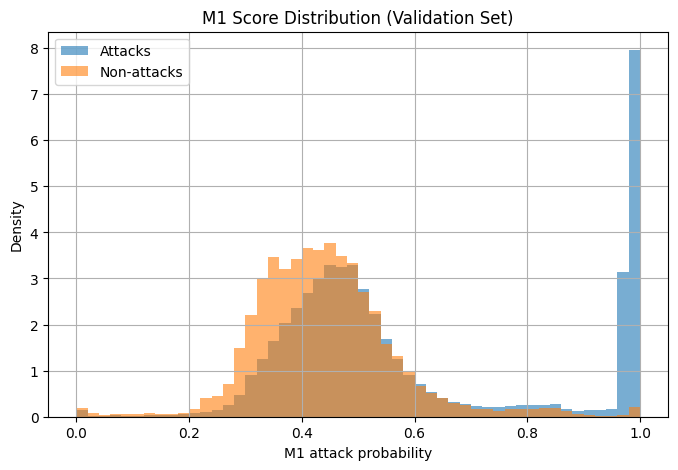

M1 overlap region:
  p_attack ∈ [0.402, 0.521]
  Overlapping samples: 23445
  Fraction of validation set: 0.3739


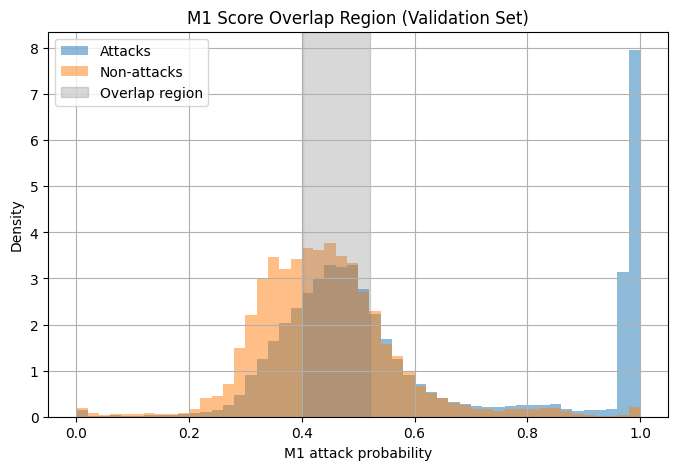


Ground-truth composition within overlap:
  Attacks: 16106 (0.687)
  Non-attacks: 7339 (0.313)

Top scenarios dominating M1 overlap:


,count,attack_ratio,scenario
marker,,,
35,2148,1.0,Relay Setting Change: R1 & R2 disabled (L1 10–...
36,2038,1.0,Relay Setting Change: R1 & R2 disabled (L1 50–...
6,1461,0.0,Fault L2 (80–90%)
5,1405,0.0,Fault L2 (20–79%)
4,1346,0.0,Fault L2 (10–19%)
30,965,1.0,Relay Setting Change: R4 disabled (L2 80–90% f...
12,932,1.0,Data Injection: L2 Fault 80–90% with tripping
10,866,1.0,Data Injection: L2 Fault 10–19% with tripping
11,829,1.0,Data Injection: L2 Fault 20–79% with tripping


In [12]:
# ------------------------------------------------------------
# 6) M1 OVERLAP ANALYSIS (VALIDATION SET)
# ------------------------------------------------------------
# Purpose:
# - Visualise M1 score distributions for attack vs non-attack
# - Identify the overlapping (ambiguous) score region
# - Analyse which scenarios dominate this overlap
#
# This explains why:
# - A single routing threshold cannot perfectly separate classes
# - Downstream refinement / fallback is required
# ------------------------------------------------------------

# Compute M1 attack probabilities (validation set)
p_attack_val = get_attack_prob(X_val)

# Split scores by ground truth
attack_scores = p_attack_val[is_attack_val]
non_attack_scores = p_attack_val[is_non_attack_val]

print("M1 Validation Set — Baseline Statistics")
print("-" * 45)

total_val = len(y_val)
total_attacks = is_attack_val.sum()
total_nonattacks = is_non_attack_val.sum()

print("Overall validation set:")
print(f"  Total samples: {total_val}")
print(f"  Attacks:       {total_attacks} ({total_attacks / total_val:.4f})")
print(f"  Non-attacks:   {total_nonattacks} ({total_nonattacks / total_val:.4f})")
# ------------------------------------------------------------
# (1) Original score distribution
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(attack_scores, bins=50, alpha=0.6, density=True, label="Attacks")
plt.hist(non_attack_scores, bins=50, alpha=0.6, density=True, label="Non-attacks")

plt.xlabel("M1 attack probability")
plt.ylabel("Density")
plt.title("M1 Score Distribution (Validation Set)")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# (2) Define overlap region (data-driven)
# ------------------------------------------------------------
LOW_Q  = 0.20   # lower tail of attacks
HIGH_Q = 0.80   # upper tail of non-attacks

overlap_low  = np.quantile(attack_scores, LOW_Q)
overlap_high = np.quantile(non_attack_scores, HIGH_Q)

overlap_mask = (
    (p_attack_val >= overlap_low) &
    (p_attack_val <= overlap_high)
)

print("M1 overlap region:")
print(f"  p_attack ∈ [{overlap_low:.3f}, {overlap_high:.3f}]")
print(f"  Overlapping samples: {overlap_mask.sum()}")
print(f"  Fraction of validation set: {overlap_mask.mean():.4f}")

# ------------------------------------------------------------
# (3) Visualise overlap explicitly
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(attack_scores, bins=50, alpha=0.5, density=True, label="Attacks")
plt.hist(non_attack_scores, bins=50, alpha=0.5, density=True, label="Non-attacks")

plt.axvspan(
    overlap_low,
    overlap_high,
    color="gray",
    alpha=0.3,
    label="Overlap region"
)

plt.xlabel("M1 attack probability")
plt.ylabel("Density")
plt.title("M1 Score Overlap Region (Validation Set)")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# (4) Ground-truth composition in overlap
# ------------------------------------------------------------
overlap_attacks = overlap_mask & is_attack_val
overlap_nonattacks = overlap_mask & is_non_attack_val

print("\nGround-truth composition within overlap:")
print(f"  Attacks: {overlap_attacks.sum()} "
      f"({overlap_attacks.sum()/overlap_mask.sum():.3f})")
print(f"  Non-attacks: {overlap_nonattacks.sum()} "
      f"({overlap_nonattacks.sum()/overlap_mask.sum():.3f})")

# ------------------------------------------------------------
# (5) Scenario-level breakdown of overlap
# ------------------------------------------------------------
overlap_df = pd.DataFrame({
    "marker": y_val[overlap_mask].values,
    "is_attack": is_attack_val[overlap_mask]
})

scenario_overlap = (
    overlap_df
    .groupby("marker")
    .agg(
        count=("is_attack", "size"),
        attack_ratio=("is_attack", "mean")
    )
    .sort_values("count", ascending=False)
)

# Add human-readable scenario names
scenario_overlap["scenario"] = scenario_overlap.index.map(
    lambda x: SCENARIO_LOOKUP.get(x, "Unknown")
)

print("\nTop scenarios dominating M1 overlap:")
display(scenario_overlap.head(15))

In [13]:
# =========================
# 7) DEFINE SAFE_MARGIN (DEFENSIBLE)
# =========================
# Safe margin = distance from TAU_GATE to the start of M1 ambiguity (overlap_low)
SAFE_MARGIN = float(max(0.0, overlap_low - TAU_GATE))

print("Derived SAFE_MARGIN =", round(SAFE_MARGIN, 4))
print("This restricts fallback to 'weak-attack' cases near the M1 ambiguous region.")

Derived SAFE_MARGIN = 0.104
This restricts fallback to 'weak-attack' cases near the M1 ambiguous region.


M3 input population:
  Total samples: 60048
  True attacks: 43276
  True non-attacks: 16772

Candidate overlap bounds:
  Attack 10% quantile:      0.743
  Non-attack 90% quantile: 0.890

⚠️ M3 overlap region detected:
  Confidence ∈ [0.743, 0.890]
  Overlap samples: 13031
  Fraction of M3 input: 0.2170

Ground-truth composition in overlap:
  Attacks: 9498 (0.729)
  Non-attacks: 3533 (0.271)


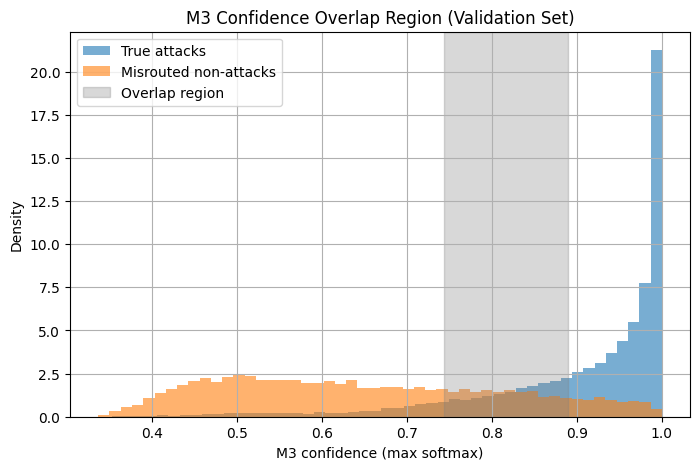


Top scenarios in M3 overlap:


,marker,count,fraction,scenario
0,37,741,0.056864,Relay Setting Change: R3 & R4 disabled (L1 10–...
1,36,679,0.052107,Relay Setting Change: R1 & R2 disabled (L1 50–...
2,6,618,0.047425,Fault L2 (80–90%)
3,5,617,0.047349,Fault L2 (20–79%)
4,41,555,0.042591,Normal Operation (no disturbances)
5,4,491,0.037679,Fault L2 (10–19%)
6,19,476,0.036528,Remote Tripping: Command Injection R1 & R2
7,7,437,0.033535,Data Injection: L1 Fault 10–19% with tripping
8,12,431,0.033075,Data Injection: L2 Fault 80–90% with tripping
9,20,429,0.032921,Remote Tripping: Command Injection R3 & R4


In [14]:
# ------------------------------------------------------------
# 8) M3 OVERLAP ANALYSIS (SINGLE CELL – VALIDATION SET)
# ------------------------------------------------------------
# Purpose:
# - Analyse M3 confidence ambiguity after M1 routing
# - Quantify overlap region
# - Show attack vs non-attack composition
# - Identify affected attack scenarios
# ------------------------------------------------------------

# -----------------------------
# Route validation samples to M3
# -----------------------------
p_attack_val = get_attack_prob(X_val)
to_M3 = p_attack_val >= TAU_GATE

X_M3 = X_val[to_M3]
y_M3 = y_val[to_M3]

is_attack_M3 = ~y_M3.isin(NON_ATTACK_IDS).to_numpy()
is_nonattack_M3 = ~is_attack_M3

print("M3 input population:")
print(f"  Total samples: {len(y_M3)}")
print(f"  True attacks: {is_attack_M3.sum()}")
print(f"  True non-attacks: {is_nonattack_M3.sum()}")

# -----------------------------
# M3 confidence extraction
# -----------------------------
m3_probs = M3.predict_proba(X_M3)
m3_conf = m3_probs.max(axis=1)

m3_conf_attack = m3_conf[is_attack_M3]
m3_conf_nonattack = m3_conf[is_nonattack_M3]

# -----------------------------
# Define overlap region SAFELY
# -----------------------------
LOW_Q  = 0.10   # lower tail of attacks
HIGH_Q = 0.90   # upper tail of non-attacks

conf_low  = np.quantile(m3_conf_attack, LOW_Q)
conf_high = np.quantile(m3_conf_nonattack, HIGH_Q)

print("\nCandidate overlap bounds:")
print(f"  Attack {LOW_Q:.0%} quantile:      {conf_low:.3f}")
print(f"  Non-attack {HIGH_Q:.0%} quantile: {conf_high:.3f}")

# -----------------------------
# Check if overlap exists
# -----------------------------
if conf_low >= conf_high:
    print("\n✅ No M3 confidence overlap detected.")
    print("M3 cleanly separates true attacks from misrouted non-attacks.")
    print("Fallback can be applied with low safety risk.")

    # Still show distribution for justification
    plt.figure(figsize=(8,5))
    plt.hist(m3_conf_attack, bins=50, alpha=0.6, density=True, label="True attacks")
    plt.hist(m3_conf_nonattack, bins=50, alpha=0.6, density=True, label="Misrouted non-attacks")
    plt.xlabel("M3 confidence (max softmax)")
    plt.ylabel("Density")
    plt.title("M3 Confidence Distribution (Validation Set)")
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    # -----------------------------
    # True overlap exists
    # -----------------------------
    m3_overlap_mask = (m3_conf >= conf_low) & (m3_conf <= conf_high)

    print("\n⚠️ M3 overlap region detected:")
    print(f"  Confidence ∈ [{conf_low:.3f}, {conf_high:.3f}]")
    print(f"  Overlap samples: {m3_overlap_mask.sum()}")
    print(f"  Fraction of M3 input: {m3_overlap_mask.mean():.4f}")

    overlap_attack = m3_overlap_mask & is_attack_M3
    overlap_nonattack = m3_overlap_mask & is_nonattack_M3

    print("\nGround-truth composition in overlap:")
    print(f"  Attacks: {overlap_attack.sum()} "
          f"({overlap_attack.sum()/m3_overlap_mask.sum():.3f})")
    print(f"  Non-attacks: {overlap_nonattack.sum()} "
          f"({overlap_nonattack.sum()/m3_overlap_mask.sum():.3f})")

    # -----------------------------
    # Visualisation
    # -----------------------------
    plt.figure(figsize=(8,5))
    plt.hist(m3_conf_attack, bins=50, alpha=0.6, density=True, label="True attacks")
    plt.hist(m3_conf_nonattack, bins=50, alpha=0.6, density=True, label="Misrouted non-attacks")
    plt.axvspan(conf_low, conf_high, color="gray", alpha=0.3, label="Overlap region")
    plt.xlabel("M3 confidence (max softmax)")
    plt.ylabel("Density")
    plt.title("M3 Confidence Overlap Region (Validation Set)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------------------------------
    # Scenario breakdown (FIXED)
    # -------------------------------
    
    # Build overlap dataframe
    overlap_df = pd.DataFrame({
        "marker": y_M3[m3_overlap_mask]
    })
    
    # Count per scenario
    scenario_df = (
        overlap_df
        .groupby("marker")
        .size()
        .reset_index(name="count")
    )
    
    # Fraction of overlap
    scenario_df["fraction"] = (
        scenario_df["count"] / scenario_df["count"].sum()
    )
    
    # Map scenario names (dataset-faithful)
    scenario_df["scenario"] = scenario_df["marker"].map(SCENARIO_LOOKUP)
    
    # Safety fallback (should not trigger if lookup is correct)
    scenario_df["scenario"] = scenario_df["scenario"].fillna(
        scenario_df["marker"].apply(lambda x: f"Unknown scenario ({x})")
    )
    
    # Sort for readability
    scenario_df = scenario_df.sort_values(
        by="count", ascending=False
    ).reset_index(drop=True)
    
    print("\nTop scenarios in M3 overlap:")
    display(scenario_df.head(10))

In [15]:
# ------------------------------------------------------------
# 9) FALLBACK THRESHOLD SELECTION (VALIDATION SET)
# ------------------------------------------------------------
# Purpose:
# Select a confidence-based fallback threshold for M3.
# The threshold is chosen to recover a target fraction of
# misrouted non-attacks while quantifying attack loss.
#
# NOTE:
# TARGET_RECOVERY is a design policy choice, not an optimised parameter.
# SAFE_MARGIN is not applied here; it is used only in the final system execution.
# ------------------------------------------------------------

TARGET_RECOVERY = 0.80  # recover 80% of misrouted non-attacks
CONF_FALLBACK = float(np.quantile(m3_conf_nonattack, TARGET_RECOVERY))

true_attack_loss = float((m3_conf_attack < CONF_FALLBACK).mean()) if len(m3_conf_attack) else 0.0
nonattack_recovery = float((m3_conf_nonattack < CONF_FALLBACK).mean()) if len(m3_conf_nonattack) else 0.0

print("Selected CONF_FALLBACK:", round(CONF_FALLBACK, 4))
print("Validation impact (simulated):")
print(" True attacks below threshold:", round(true_attack_loss, 4))
print(" Misrouted non-attacks recovered:", round(nonattack_recovery, 4))

Selected CONF_FALLBACK: 0.8133
Validation impact (simulated):
 True attacks below threshold: 0.1751
 Misrouted non-attacks recovered: 0.7962


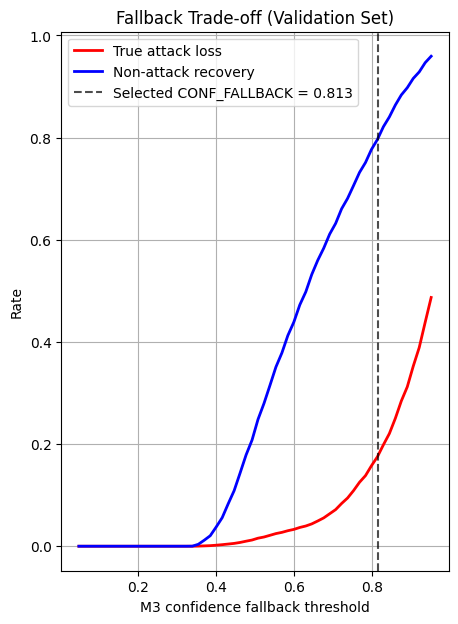

In [16]:
# ------------------------------------------------------------
# 10) FALLBACK IMPACT METRICS (VALIDATION SET)
# ------------------------------------------------------------
# Purpose:
# Quantify the inherent trade-off introduced by confidence-based fallback:
# - True attack loss (safety risk)
# - Non-attack recovery (clean-up benefit)
#
# NOTE:
# This analysis evaluates fallback based on M3 confidence alone
# to characterise the intrinsic trade-off.
# Additional safeguards (e.g., SAFE_MARGIN on M1 output)
# are applied only in the final end-to-end system.
#
# Analysis only — no fallback is applied to predictions here.
# ------------------------------------------------------------

conf_thresholds = np.linspace(0.05, 0.95, 60)
records = []

for conf_fb in conf_thresholds:
    fallback_mask = (m3_conf < conf_fb)

    attack_loss = (fallback_mask & is_attack_M3).sum() / max(1, is_attack_M3.sum())
    nonattack_recovery = (
        (fallback_mask & is_nonattack_M3).sum() / max(1, is_nonattack_M3.sum())
    )

    records.append({
        "CONF_FALLBACK": conf_fb,
        "attack_loss_rate": attack_loss,
        "nonattack_recovery_rate": nonattack_recovery
    })

fallback_df = pd.DataFrame(records)

# ------------------------------------------------------------
# Visualise trade-off
# ------------------------------------------------------------
plt.figure(figsize=(5, 7))

plt.plot(
    fallback_df["CONF_FALLBACK"],
    fallback_df["attack_loss_rate"],
    label="True attack loss",
    linewidth=2,
    color="red"
)

plt.plot(
    fallback_df["CONF_FALLBACK"],
    fallback_df["nonattack_recovery_rate"],
    label="Non-attack recovery",
    linewidth=2,
    color="blue"
)

# Mark selected operating point
plt.axvline(
    CONF_FALLBACK,
    linestyle="--",
    color="black",
    alpha=0.7,
    label=f"Selected CONF_FALLBACK = {CONF_FALLBACK:.3f}"
)

plt.xlabel("M3 confidence fallback threshold")
plt.ylabel("Rate")
plt.title("Fallback Trade-off (Validation Set)")
plt.legend()
plt.grid(True)
plt.show()


In [23]:
# ------------------------------------------------------------
# 11) SAFE FALLBACK RULE (FINAL LOGIC)
# ------------------------------------------------------------
# Purpose:
# Apply confidence-based fallback only when BOTH:
# (1) M3 is uncertain, and
# (2) M1 indicates a weak attack near the decision boundary.
# This protects high-confidence attack detections.
# ------------------------------------------------------------

p_attack_M3 = p_attack_val[to_M3]
fallback_mask = (m3_conf < CONF_FALLBACK) & (p_attack_M3 < TAU_GATE + SAFE_MARGIN)

print("Fallback triggered (val):", fallback_mask.sum(), f"({fallback_mask.mean()* 100:.2f} % of M3 inputs)")

attack_loss_rate = float((fallback_mask & is_attack_M3).sum() / max(1, is_attack_M3.sum()))
nonattack_recovery_rate = float((fallback_mask & is_nonattack_M3).sum() / max(1, is_nonattack_M3.sum()))

print("With SAFE_MARGIN rule (val):")
print(" Attack loss rate:", f"{attack_loss_rate * 100:.2f}%")
print(" Non-attack recovery rate:", f"{nonattack_recovery_rate * 100:.2f}%")

Fallback triggered (val): 6439 (10.72 % of M3 inputs)
With SAFE_MARGIN rule (val):
 Attack loss rate: 3.64%
 Non-attack recovery rate: 29.00%


In [24]:
# =========================
# 12) SUMMARY TABLE (END OF NOTEBOOK)
# =========================
summary = pd.DataFrame([
    {"Stage": "M1 routing", "Observation": f"Overlap ~ {overlap_mask.mean():.3f} of val", "Implication": "Single threshold insufficient"},
    {"Stage": "M3 confidence", "Observation": f"Low-confidence overlap exists", "Implication": "Confidence can signal ambiguity"},
    {"Stage": "Fallback", "Observation": f"CONF_FALLBACK={CONF_FALLBACK:.4f}, SAFE_MARGIN={SAFE_MARGIN:.4f}", "Implication": "Recovery vs safety trade-off"},
])
display(summary)


,Stage,Observation,Implication
0,M1 routing,Overlap ~ 0.374 of val,Single threshold insufficient
1,M3 confidence,Low-confidence overlap exists,Confidence can signal ambiguity
2,Fallback,"CONF_FALLBACK=0.8133, SAFE_MARGIN=0.1040",Recovery vs safety trade-off


### 13) Final Takeaway

This analysis shows that ambiguity in power-system intrusion detection is inherent rather than a modelling flaw. 
Confidence-based fallback can reduce misrouted non-attacks but introduces a safety trade-off, requiring conservative thresholds and additional safeguards. 
The resulting SAFE fallback rule is carried forward into the end-to-end system evaluation.


NameError: name 'i' is not defined